In [10]:
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [11]:
target_rel = Path("2_Train_FaceRecognition_with_ML") / "data" / "Dataset.csv"
WORKSPACE = None

for p in [Path.cwd(), *Path.cwd().parents]:
    if (p / target_rel).exists():
        WORKSPACE = p
        break

if WORKSPACE is None:
    raise FileNotFoundError(f"Could not find {target_rel} from {Path.cwd()}")

BASE = WORKSPACE / "2_Train_FaceRecognition_with_ML" / "data"
CSV_PATH = BASE / "Dataset.csv"
CROP_ROOT = BASE / "Faces" / "Faces"

print("Workspace:", WORKSPACE)
print("CSV exists:", CSV_PATH.exists(), CSV_PATH)
print("Crop dir exists:", CROP_ROOT.exists(), CROP_ROOT)

Workspace: c:\Users\schha\attendify_scratch
CSV exists: True c:\Users\schha\attendify_scratch\2_Train_FaceRecognition_with_ML\data\Dataset.csv
Crop dir exists: True c:\Users\schha\attendify_scratch\2_Train_FaceRecognition_with_ML\data\Faces\Faces


In [12]:
df = pd.read_csv(CSV_PATH)

required_cols = {"id", "label"}
missing_cols = required_cols - set(df.columns)
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

df["crop_path"] = df["id"].apply(lambda x: CROP_ROOT / x)
df["crop_exists"] = df["crop_path"].apply(Path.exists)

usable_df = df[df["crop_exists"]].copy()

print("Total rows:", len(df))
print("Usable rows with crop:", len(usable_df))
print("Dropped rows:", len(df) - len(usable_df))
print("Unique labels in usable data:", usable_df["label"].nunique())
usable_df.head()

Total rows: 2562
Usable rows with crop: 2475
Dropped rows: 87
Unique labels in usable data: 31


,id,label,crop_path,crop_exists
0,Robert Downey Jr_87.jpg,Robert Downey Jr,c:\Users\schha\attendify_scratch\2_Train_FaceR...,True
1,Lisa Kudrow_64.jpg,Lisa Kudrow,c:\Users\schha\attendify_scratch\2_Train_FaceR...,True
2,Ellen Degeneres_34.jpg,Ellen Degeneres,c:\Users\schha\attendify_scratch\2_Train_FaceR...,True
5,Vijay Deverakonda_39.jpg,Vijay Deverakonda,c:\Users\schha\attendify_scratch\2_Train_FaceR...,True
6,Tom Cruise_21.jpg,Tom Cruise,c:\Users\schha\attendify_scratch\2_Train_FaceR...,True


In [ ]:
IMG_SIZE = (160, 160)  # (width, height)

X_list = []
y_list = []

for _, row in usable_df.iterrows():
    img = cv2.imread(str(row["crop_path"]), cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue

    if (img.shape[1], img.shape[0]) != IMG_SIZE:
        img = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA)

    img = img.astype(np.float32) / 255.0 # Normalize to [0, 1]
    vec = img.flatten()  # 160 x 160 -> 25600
    X_list.append(vec)
    y_list.append(row["label"])

X = np.array(X_list, dtype=np.float32)
y = np.array(y_list)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Features per image:", X.shape[1])
print(X)
print(y)

[[63 63 64 ... 19 24 30]
 [65 65 65 ... 19 24 31]
 [64 65 65 ... 19 24 32]
 ...
 [40 40 40 ... 48 49 50]
 [40 40 40 ... 49 50 49]
 [41 41 41 ... 49 49 46]]
[[221 250 255 ... 255 255 255]
 [221 250 255 ... 255 255 255]
 [221 250 255 ... 255 255 255]
 ...
 [121 103  80 ... 113 116 118]
 [121 103  81 ... 129 133 136]
 [121 103  81 ... 138 143 147]]
[[ 3  2  2 ...  0  0  0]
 [ 2  2  2 ...  0  0  0]
 [ 1  2  3 ...  0  0  0]
 ...
 [ 0  0  0 ... 20 20 18]
 [ 0  0  0 ... 23 23 21]
 [ 0  0  0 ... 18 17 16]]
[[165 182 189 ... 147 146 153]
 [148 151 161 ... 136 145 149]
 [169 164 149 ... 132 137 136]
 ...
 [219 221 224 ... 180 200 205]
 [218 222 223 ... 205 209 212]
 [217 221 221 ... 213 214 222]]
[[242 242 242 ... 246 246 246]
 [242 242 242 ... 246 246 246]
 [241 241 241 ... 246 246 246]
 ...
 [222 223 223 ...  26  24  28]
 [222 223 223 ...  24  19  24]
 [223 223 222 ...  22  22  23]]
[[ 60  47  37 ... 248 253 250]
 [ 50  38  30 ... 251 244 251]
 [ 37  31  25 ... 250 245 250]
 ...
 [ 52  50  60 

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1980, 25600)
X_test shape: (495, 25600)
y_train shape: (1980,)
y_test shape: (495,)


[0.47655773 0.4756037  0.4747779  ... 0.4048498  0.4073866  0.40760815]  ->  (25600,)
[[0.47655773 0.4756037  0.4747779  ... 0.4714044  0.47575772 0.47813225]
 [0.47571066 0.47474962 0.47211325 ... 0.47161418 0.47627658 0.47848493]
 [0.47446868 0.47195345 0.47034094 ... 0.4702869  0.47484642 0.47789237]
 ...
 [0.42195162 0.4209199  0.41795674 ... 0.4059808  0.40884802 0.4090486 ]
 [0.41946772 0.41833487 0.41574088 ... 0.40524355 0.40690085 0.40864384]
 [0.4180162  0.4140593  0.41220304 ... 0.4048498  0.4073866  0.40760815]]


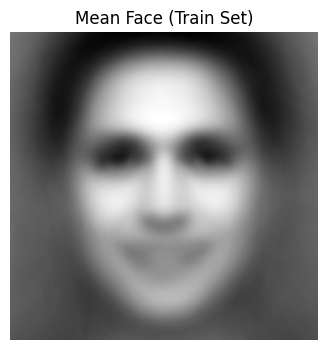

In [17]:
mean_face_vector = X_train.mean(axis=0)
mean_face_img = mean_face_vector.reshape(IMG_SIZE[1], IMG_SIZE[0])
print(mean_face_vector, " -> ", mean_face_vector.shape)
print(mean_face_img)

plt.figure(figsize=(4, 4))
plt.imshow(mean_face_img, cmap="gray")
plt.title("Mean Face (Train Set)")
plt.axis("off")
plt.show()

In [21]:
X_train_centered = X_train - mean_face_vector
X_test_centered = X_test - mean_face_vector

print("Centered train shape:", X_train_centered.shape)
print("Centered test shape:", X_test_centered.shape)
print("Mean of centered train (should be near 0):", float(X_train_centered.mean()))

Centered train shape: (1980, 25600)
Centered test shape: (495, 25600)
Mean of centered train (should be near 0): -2.2656989528968552e-07


In [22]:
n_components = 100

pca = PCA(
    n_components=n_components,
    svd_solver="randomized",
    whiten=True,
    random_state=42
)

pca.fit(X_train_centered)

X_train_pca = pca.transform(X_train_centered)
X_test_pca = pca.transform(X_test_centered)

print("PCA train shape:", X_train_pca.shape)
print("PCA test shape:", X_test_pca.shape)
print("Explained variance ratio (first 5):", pca.explained_variance_ratio_[:5])
print("Total explained variance (100 comps):", float(np.sum(pca.explained_variance_ratio_)))

PCA train shape: (1980, 100)
PCA test shape: (495, 100)
Explained variance ratio (first 5): [0.26445672 0.09234335 0.08094961 0.04856886 0.04102996]
Total explained variance (100 comps): 0.8803715705871582


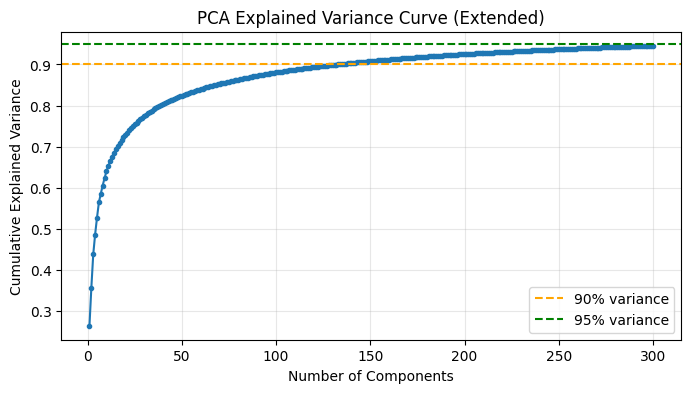

k_90: 133
k_95: Not reached


In [25]:
# Refit with more components first (example 300) so thresholds can be reached
pca_big = PCA(
    n_components=300,
    svd_solver="randomized",
    whiten=True,
    random_state=42
)
pca_big.fit(X_train_centered)

cum_var_big = np.cumsum(pca_big.explained_variance_ratio_)

# Safe threshold detection
idx90 = np.where(cum_var_big >= 0.90)[0]
idx95 = np.where(cum_var_big >= 0.95)[0]

k_90 = int(idx90[0] + 1) if len(idx90) > 0 else None
k_95 = int(idx95[0] + 1) if len(idx95) > 0 else None

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cum_var_big) + 1), cum_var_big, marker=".")
plt.axhline(0.90, color="orange", linestyle="--", label="90% variance")
plt.axhline(0.95, color="green", linestyle="--", label="95% variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance Curve (Extended)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("k_90:", k_90 if k_90 is not None else "Not reached")
print("k_95:", k_95 if k_95 is not None else "Not reached")

In [26]:
k_opt = 133  # from k_90

pca_opt = PCA(
    n_components=k_opt,
    svd_solver="randomized",
    whiten=True,
    random_state=42
)
pca_opt.fit(X_train_centered)

X_train_pca_opt = pca_opt.transform(X_train_centered)
X_test_pca_opt = pca_opt.transform(X_test_centered)

print("Optimized PCA train shape:", X_train_pca_opt.shape)
print("Optimized PCA test shape:", X_test_pca_opt.shape)
print("Explained variance (k_opt):", float(np.sum(pca_opt.explained_variance_ratio_)))

Optimized PCA train shape: (1980, 133)
Optimized PCA test shape: (495, 133)
Explained variance (k_opt): 0.900206983089447


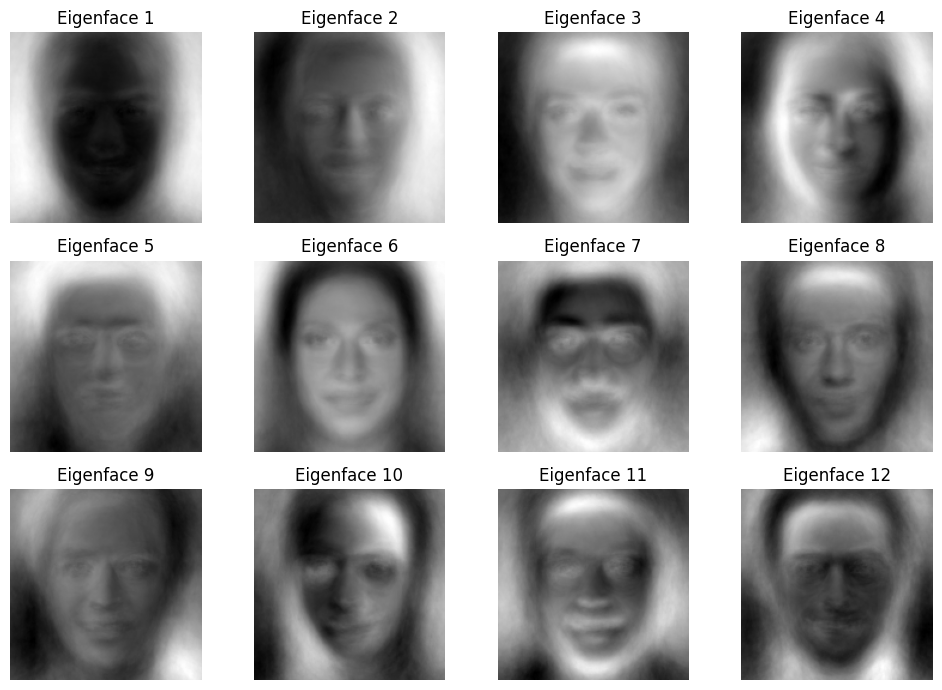

In [27]:
n_show = 12
rows, cols = 3, 4

plt.figure(figsize=(10, 7))
for i in range(min(n_show, pca_opt.components_.shape[0])):
    eigenface = pca_opt.components_[i].reshape(IMG_SIZE[1], IMG_SIZE[0])
    plt.subplot(rows, cols, i + 1)
    plt.imshow(eigenface, cmap="gray")
    plt.title(f"Eigenface {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [28]:
import pickle

MODEL_OUT = BASE / "models"
MODEL_OUT.mkdir(parents=True, exist_ok=True)

pca_bundle = {
    "img_size": IMG_SIZE,
    "mean_face_vector": mean_face_vector,
    "pca_model": pca_opt,
    "k_opt": k_opt
}

bundle_path = MODEL_OUT / "eigenface_pca_bundle.pkl"
with open(bundle_path, "wb") as f:
    pickle.dump(pca_bundle, f)

print("Saved PCA bundle to:", bundle_path)

Saved PCA bundle to: c:\Users\schha\attendify_scratch\2_Train_FaceRecognition_with_ML\data\models\eigenface_pca_bundle.pkl
